# Face → Anime — Test Set Evaluation

Runs the trained CycleGAN generator on a random sample of images from
`data/processed/real_test/real_test.json`, saves the results into
`outputs/test_predictions/`, and displays them inline for a quick visual
check.

Run this from the project root (or adjust `PROJECT_ROOT` below).

In [100]:
import json
import random
import sys
from pathlib import Path

import torch
from PIL import Image, UnidentifiedImageError
from torchvision import transforms
import matplotlib.pyplot as plt
PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

sys.path.insert(0, str(PROJECT_ROOT))

from src.inference import load_generator, run_inference, save_image, denormalize

print("Project root:", PROJECT_ROOT)

Project root: c:\Users\Dileep Kumar\Desktop\Face-Anime-AI


## Config — change these as needed

In [101]:
CHECKPOINT_PATH = PROJECT_ROOT / "checkpoints" / "epoch_024.pth"
TEST_JSON_PATH = PROJECT_ROOT / "data" / "processed" / "real_test" / "real_test.json"
RAW_DATA_DIR = PROJECT_ROOT / "data" / "raw_data" / "real"

OUTPUT_DIR = PROJECT_ROOT / "outputs" / "test_predictions"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

NUM_SAMPLES = 20          
SEED = 42                 
SAVE_SIDE_BY_SIDE = True  
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", DEVICE)

Device: cuda


## Load the trained generator

In [102]:
generator = load_generator(str(CHECKPOINT_PATH), DEVICE)
print(f"Loaded generator from {CHECKPOINT_PATH}")

Loaded generator from c:\Users\Dileep Kumar\Desktop\Face-Anime-AI\checkpoints\epoch_024.pth


## Load the test list and sample from it

In [103]:
with open(TEST_JSON_PATH, "r") as f:
    all_paths = json.load(f)

print(f"Test JSON has {len(all_paths)} entries")

random.seed(SEED)
sample_paths = random.sample(all_paths, min(NUM_SAMPLES, len(all_paths)))
sample_paths[:5]

Test JSON has 10000 entries


['C:\\Users\\Dileep Kumar\\Desktop\\Face-Anime-AI\\data\\raw_data\\real\\035475.jpg',
 'C:\\Users\\Dileep Kumar\\Desktop\\Face-Anime-AI\\data\\raw_data\\real\\033184.jpg',
 'C:\\Users\\Dileep Kumar\\Desktop\\Face-Anime-AI\\data\\raw_data\\real\\022521.jpg',
 'C:\\Users\\Dileep Kumar\\Desktop\\Face-Anime-AI\\data\\raw_data\\real\\021058.jpg',
 'C:\\Users\\Dileep Kumar\\Desktop\\Face-Anime-AI\\data\\raw_data\\real\\040265.jpg']

## Resolve each path

The JSON stores absolute paths from whatever machine originally built it
(often Windows-style, e.g. `C:\Users\...`). If that exact path doesn't
exist here, fall back to looking the file up by filename in `RAW_DATA_DIR`.

In [104]:
def resolve_image_path(raw_path: str, raw_data_dir: Path):
    candidate = Path(raw_path)
    if candidate.exists():
        return candidate

    filename = raw_path.replace("\\", "/").split("/")[-1]
    fallback = raw_data_dir / filename
    if fallback.exists():
        return fallback

    return None

## Run inference on the sample, save results, and display them inline

In [105]:
results = []
skipped = []

for raw_path in sample_paths:
    resolved = resolve_image_path(raw_path, RAW_DATA_DIR)
    if resolved is None:
        skipped.append(raw_path)
        continue

    try:
        original_image = Image.open(resolved).convert("RGB")
    except (UnidentifiedImageError, OSError):
        skipped.append(raw_path)
        continue

    fake_anime = run_inference(generator, original_image, DEVICE)

    out_path = OUTPUT_DIR / f"anime_{resolved.stem}.jpg"
    save_image(fake_anime, out_path)

    gen_tensor = denormalize(fake_anime).clamp(0, 1)
    gen_image = transforms.ToPILImage()(gen_tensor)

    if SAVE_SIDE_BY_SIDE:
        gen_resized = gen_image.resize(original_image.size)
        combined = Image.new("RGB", (original_image.width * 2, original_image.height))
        combined.paste(original_image, (0, 0))
        combined.paste(gen_resized, (original_image.width, 0))
        combined.save(OUTPUT_DIR / f"compare_{resolved.stem}.jpg")

    results.append((original_image, gen_image, resolved.stem))

print(f"Generated {len(results)} images, skipped {len(skipped)}")
if skipped:
    print("Skipped (not found / unreadable):")
    for p in skipped:
        print(" ", p)

Saved: c:\Users\Dileep Kumar\Desktop\Face-Anime-AI\outputs\test_predictions\anime_035475.jpg
Saved: c:\Users\Dileep Kumar\Desktop\Face-Anime-AI\outputs\test_predictions\anime_033184.jpg
Saved: c:\Users\Dileep Kumar\Desktop\Face-Anime-AI\outputs\test_predictions\anime_022521.jpg
Saved: c:\Users\Dileep Kumar\Desktop\Face-Anime-AI\outputs\test_predictions\anime_021058.jpg
Saved: c:\Users\Dileep Kumar\Desktop\Face-Anime-AI\outputs\test_predictions\anime_040265.jpg
Saved: c:\Users\Dileep Kumar\Desktop\Face-Anime-AI\outputs\test_predictions\anime_007482.jpg
Saved: c:\Users\Dileep Kumar\Desktop\Face-Anime-AI\outputs\test_predictions\anime_012045.jpg
Saved: c:\Users\Dileep Kumar\Desktop\Face-Anime-AI\outputs\test_predictions\anime_034563.jpg
Saved: c:\Users\Dileep Kumar\Desktop\Face-Anime-AI\outputs\test_predictions\anime_040538.jpg
Saved: c:\Users\Dileep Kumar\Desktop\Face-Anime-AI\outputs\test_predictions\anime_011128.jpg
Saved: c:\Users\Dileep Kumar\Desktop\Face-Anime-AI\outputs\test_predic

## View all results together

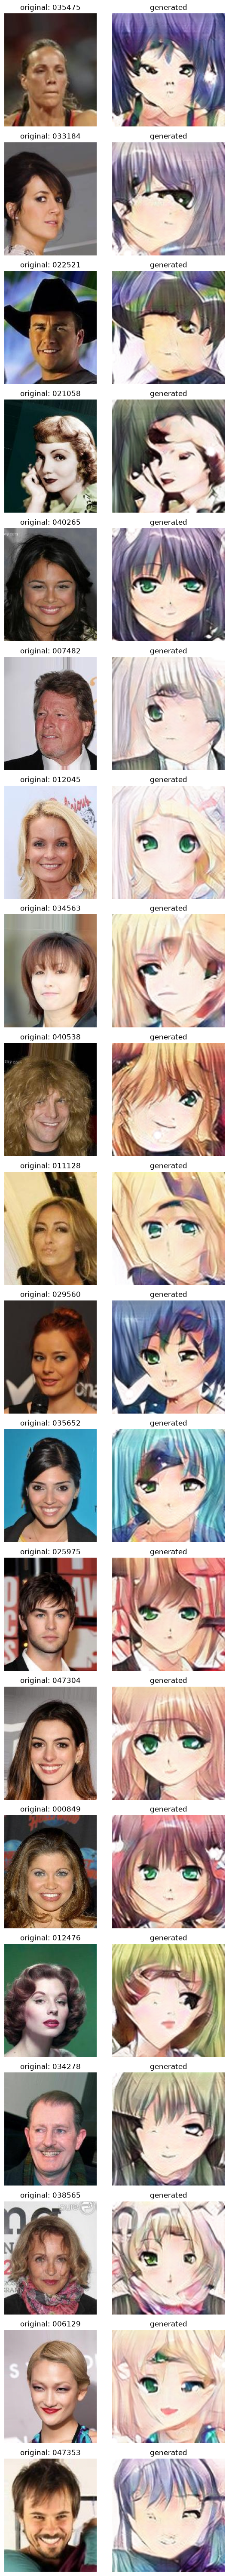


All saved images are in: c:\Users\Dileep Kumar\Desktop\Face-Anime-AI\outputs\test_predictions


In [106]:
n = len(results)
fig, axes = plt.subplots(n, 2, figsize=(6, 3 * n))
if n == 1:
    axes = [axes]

for row, (original_image, gen_image, name) in zip(axes, results):
    row[0].imshow(original_image)
    row[0].set_title(f"original: {name}")
    row[0].axis("off")

    row[1].imshow(gen_image)
    row[1].set_title("generated")
    row[1].axis("off")

plt.tight_layout()
plt.show()

print(f"\nAll saved images are in: {OUTPUT_DIR}")

## Epoch journey — one image, transformed by every saved checkpoint

Loads every `epoch_*.pth` checkpoint in `checkpoints/`, runs the **same**
input image through each one, and shows how the output changes over
training — labeled with the actual epoch number stored inside each
checkpoint file (not just guessed from the filename).

Using the first sampled image from the earlier step.


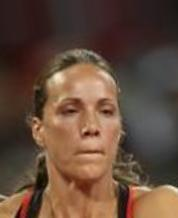

In [107]:
import re

CHECKPOINT_DIR = PROJECT_ROOT / "checkpoints"
JOURNEY_OUTPUT_DIR = PROJECT_ROOT / "outputs" / "epoch_journey"
JOURNEY_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
JOURNEY_IMAGE_PATH = None

if JOURNEY_IMAGE_PATH is None:
    if results:
        journey_image = results[0][0] 
        print("Using the first sampled image from the earlier step.")
    else:
        raise RuntimeError(
            "No sampled images available. Either run the earlier sampling "
            "cells first, or set JOURNEY_IMAGE_PATH to a specific file."
        )
else:
    journey_image = Image.open(JOURNEY_IMAGE_PATH).convert("RGB")

journey_image

In [108]:
checkpoint_files = sorted(CHECKPOINT_DIR.glob("epoch_*.pth"))

if not checkpoint_files:
    raise RuntimeError(f"No epoch_*.pth checkpoints found in {CHECKPOINT_DIR}")

print(f"Found {len(checkpoint_files)} checkpoints in {CHECKPOINT_DIR}")
checkpoint_epochs = []
for ckpt_path in checkpoint_files:
    raw = torch.load(ckpt_path, map_location="cpu")
    if isinstance(raw, dict) and "epoch" in raw:
        epoch_num = raw["epoch"]
    else:
        match = re.search(r"(\d+)", ckpt_path.stem)
        epoch_num = int(match.group(1)) if match else None
    checkpoint_epochs.append((epoch_num, ckpt_path))

checkpoint_epochs.sort(key=lambda pair: (pair[0] is None, pair[0]))
checkpoint_epochs[:5]

Found 25 checkpoints in c:\Users\Dileep Kumar\Desktop\Face-Anime-AI\checkpoints


[(1,
  WindowsPath('c:/Users/Dileep Kumar/Desktop/Face-Anime-AI/checkpoints/epoch_001.pth')),
 (2,
  WindowsPath('c:/Users/Dileep Kumar/Desktop/Face-Anime-AI/checkpoints/epoch_002.pth')),
 (3,
  WindowsPath('c:/Users/Dileep Kumar/Desktop/Face-Anime-AI/checkpoints/epoch_003.pth')),
 (4,
  WindowsPath('c:/Users/Dileep Kumar/Desktop/Face-Anime-AI/checkpoints/epoch_004.pth')),
 (5,
  WindowsPath('c:/Users/Dileep Kumar/Desktop/Face-Anime-AI/checkpoints/epoch_005.pth'))]

In [109]:
journey_frames = [] 

for epoch_num, ckpt_path in checkpoint_epochs:
    gen = load_generator(str(ckpt_path), DEVICE)
    fake_anime = run_inference(gen, journey_image, DEVICE)

    gen_tensor = denormalize(fake_anime).clamp(0, 1)
    gen_image = transforms.ToPILImage()(gen_tensor)

    label = f"epoch_{epoch_num:03d}" if epoch_num is not None else ckpt_path.stem
    gen_image.save(JOURNEY_OUTPUT_DIR / f"{label}.jpg")

    journey_frames.append((epoch_num, gen_image))
    print(f"  processed {ckpt_path.name} -> epoch {epoch_num}")

print(f"\nDone. {len(journey_frames)} frames saved to {JOURNEY_OUTPUT_DIR}")

  processed epoch_001.pth -> epoch 1
  processed epoch_002.pth -> epoch 2
  processed epoch_003.pth -> epoch 3
  processed epoch_004.pth -> epoch 4
  processed epoch_005.pth -> epoch 5
  processed epoch_006.pth -> epoch 6
  processed epoch_007.pth -> epoch 7
  processed epoch_008.pth -> epoch 8
  processed epoch_009.pth -> epoch 9
  processed epoch_010.pth -> epoch 10
  processed epoch_011.pth -> epoch 11
  processed epoch_012.pth -> epoch 12
  processed epoch_013.pth -> epoch 13
  processed epoch_014.pth -> epoch 14
  processed epoch_015.pth -> epoch 15
  processed epoch_016.pth -> epoch 16
  processed epoch_017.pth -> epoch 17
  processed epoch_018.pth -> epoch 18
  processed epoch_019.pth -> epoch 19
  processed epoch_020.pth -> epoch 20
  processed epoch_021.pth -> epoch 21
  processed epoch_022.pth -> epoch 22
  processed epoch_023.pth -> epoch 23
  processed epoch_024.pth -> epoch 24
  processed epoch_025.pth -> epoch 25

Done. 25 frames saved to c:\Users\Dileep Kumar\Desktop\Fac

### View the full journey

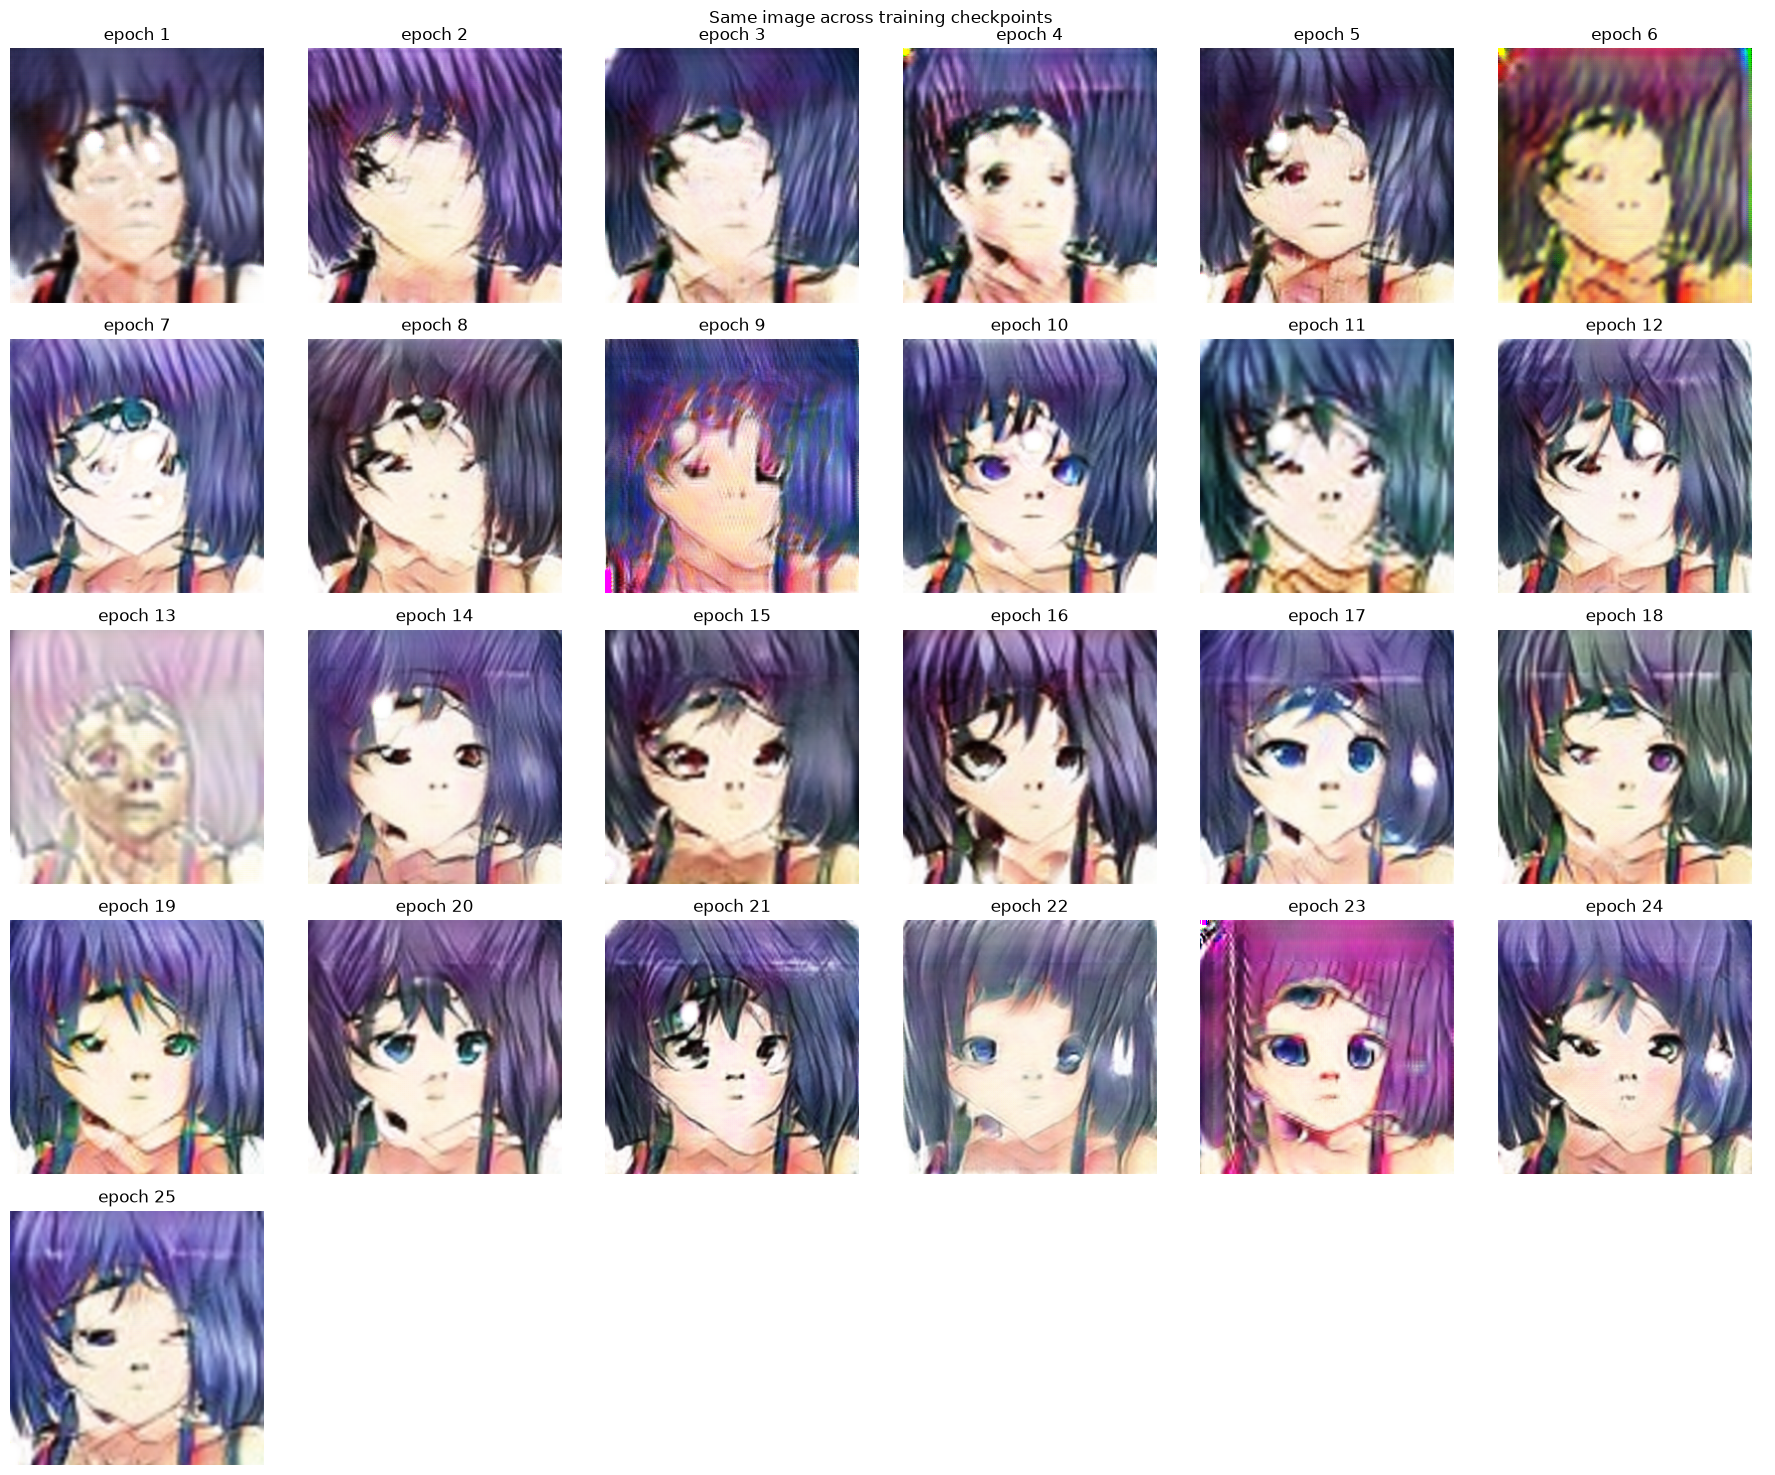

In [110]:
n = len(journey_frames)
cols = min(6, n)
rows = (n + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(3 * cols, 3 * rows))
axes = axes.flatten() if n > 1 else [axes]

for ax, (epoch_num, frame) in zip(axes, journey_frames):
    ax.imshow(frame)
    title = f"epoch {epoch_num}" if epoch_num is not None else "epoch ?"
    ax.set_title(title)
    ax.axis("off")
for ax in axes[n:]:
    ax.axis("off")

plt.suptitle("Same image across training checkpoints")
plt.tight_layout()
plt.show()